<a href="https://colab.research.google.com/github/ViniUK00/NorthStar-Analytics-Coursework/blob/main/SQL_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility: Relational Data Processing & Analytics
**Business Objective:** Management needs to identify which city zones are underperforming and determine the root cause of missed delivery windows. This section integrates operational datasets to calculate failure rates and manual route overrides across all geographical zones.


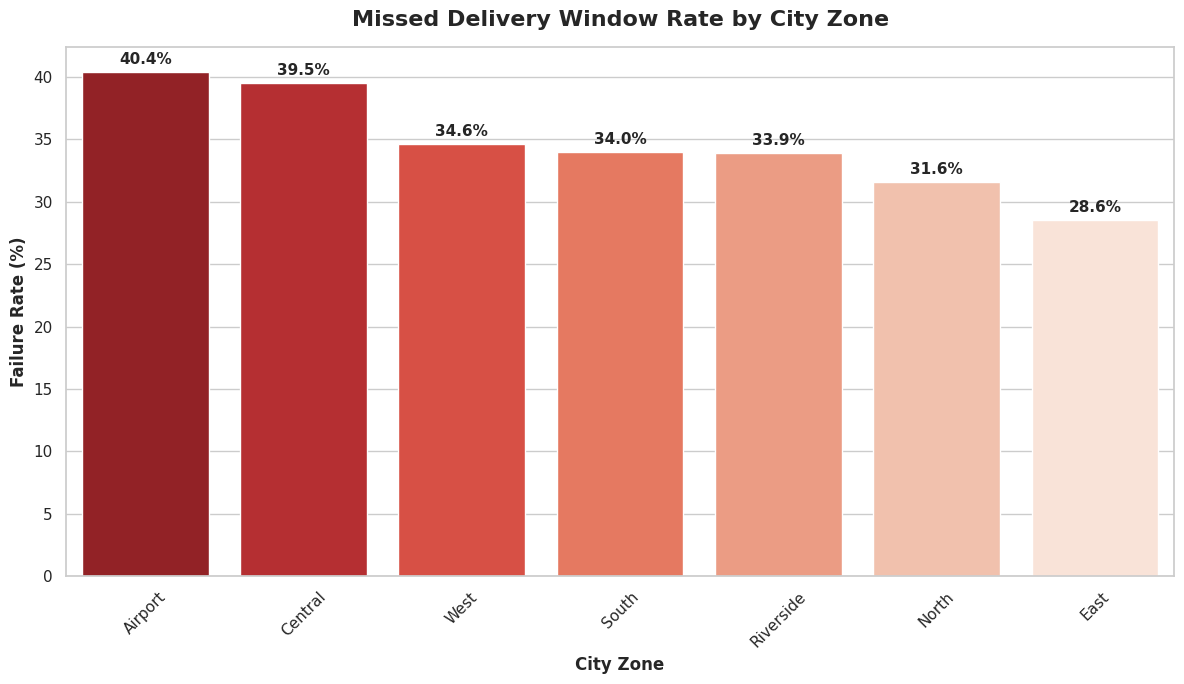


--- Detailed Zone Performance Analytics ---
     zone  failure_rate_pct  avg_overrides
  Airport             40.38           0.91
  Central             39.51           1.03
     West             34.65           0.87
    South             33.96           0.92
Riverside             33.91           1.05
    North             31.62           1.03
     East             28.57           0.89


In [2]:
# Install libraries
!pip install pandas matplotlib seaborn -q

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# LOAD THE DATA
base_url = "https://raw.githubusercontent.com/ViniUK00/NorthStar-Analytics-Coursework/refs/heads/main/"
deliveries = pd.read_csv(base_url + "deliveries.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
incidents = pd.read_csv(base_url + "incidents.csv")

# DATA CLEANING & PREPARATION
deliveries.drop_duplicates(inplace=True)
hubs.drop_duplicates(inplace=True)

if 'manual_route_override_count' in deliveries.columns:
    deliveries['manual_route_override_count'] = deliveries['manual_route_override_count'].fillna(0)

deliveries.dropna(subset=['hub_id', 'delivery_id'], inplace=True)
hubs.dropna(subset=['hub_id'], inplace=True)

if 'zone' in hubs.columns:
    hubs['zone'] = hubs['zone'].astype(str).str.strip().str.title()

# DATA PROCESSING & MERGING
merged_data = pd.merge(deliveries, hubs, on="hub_id", how="left")

# Binary column for missed deliveries (1 for Failed/Delayed, 0 for OnTime)
merged_data['missed_delivery_window'] = merged_data['delivery_status'].apply(lambda x: 1 if x in ['Failed', 'Delayed'] else 0)

# ANALYTICS
zone_performance = merged_data.groupby('zone').agg(
    total_deliveries=('delivery_id', 'count'),
    missed_windows=('missed_delivery_window', 'sum'),
    avg_overrides=('manual_route_override_count', 'mean')
).reset_index()

zone_performance['failure_rate_pct'] = (zone_performance['missed_windows'] / zone_performance['total_deliveries']) * 100

# Sort values to show worst-performing zones first
zone_performance_sorted = zone_performance.sort_values('failure_rate_pct', ascending=False)

# VISUALISATION
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid") # Adds a clean, professional grid background

# Added 'hue' and 'legend=False' to fix the Future Warning
ax = sns.barplot(
    data=zone_performance_sorted,
    x='zone',
    y='failure_rate_pct',
    hue='zone',
    palette='Reds_r',
    legend=False
)

# Professional Titles and Labels
plt.title('Missed Delivery Window Rate by City Zone', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Failure Rate (%)', fontsize=12, fontweight='bold')
plt.xlabel('City Zone', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, fontsize=11)

# Add data labels directly on top of the bars
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.1f') + '%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Display the data table for detailed review
print("\n--- Detailed Zone Performance Analytics ---")
print(zone_performance_sorted[['zone', 'failure_rate_pct', 'avg_overrides']].round(2).to_string(index=False))

In [8]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Ensure timestamps are in datetime format first
merged_data['dispatch_time'] = pd.to_datetime(merged_data['dispatch_time'])
merged_data['delivery_completed_at'] = pd.to_datetime(merged_data['delivery_completed_at'])

merged_data['delivery_duration_hours'] = (
    merged_data['delivery_completed_at'] - merged_data['dispatch_time']
).dt.total_seconds() / 3600

df_reg = merged_data.dropna(subset=['manual_route_override_count', 'delivery_duration_hours'])

X = df_reg[['manual_route_override_count']]
y = df_reg['delivery_duration_hours']

model = LinearRegression()
model.fit(X, y)

# Predict: If a driver overrides the route 3 times, how long will the delivery take?
predicted_val = model.predict(np.array([[3]]))[0]

print(f"Regression Coefficient: {model.coef_[0]:.2f}")
print(f"Prediction: 3 manual overrides are expected to result in a {predicted_val:.2f} hour delivery.")

Regression Coefficient: -0.11
Prediction: 3 manual overrides are expected to result in a 9.32 hour delivery.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


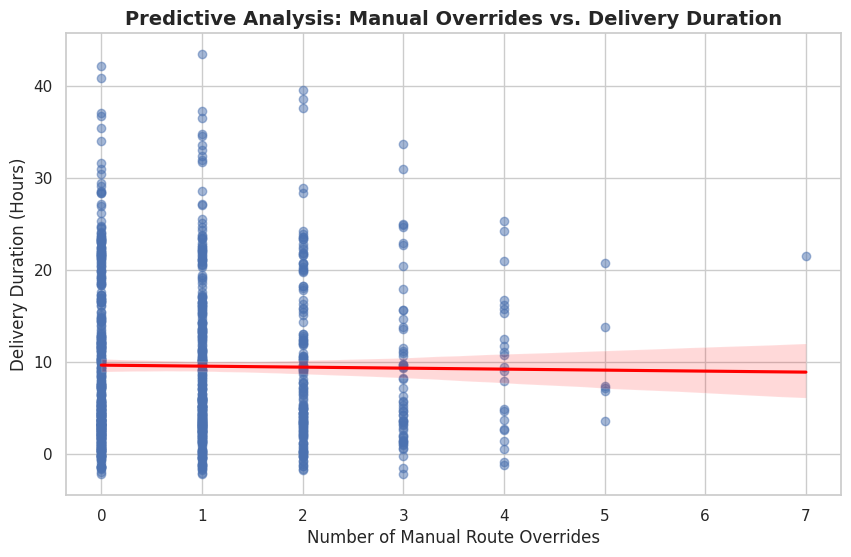

Prediction: 3 manual overrides are expected to result in a 9.32 hour delivery.


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

future_override_df = pd.DataFrame([[3]], columns=['manual_route_override_count'])
predicted_val = model.predict(future_override_df)[0]

plt.figure(figsize=(10, 6))
sns.regplot(data=df_reg, x='manual_route_override_count', y='delivery_duration_hours',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Predictive Analysis: Manual Overrides vs. Delivery Duration', fontsize=14, fontweight='bold')
plt.xlabel('Number of Manual Route Overrides', fontsize=12)
plt.ylabel('Delivery Duration (Hours)', fontsize=12)
plt.show()

print(f"Prediction: 3 manual overrides are expected to result in a {predicted_val:.2f} hour delivery.")

##Predictive Insights: Forecasting Operational Delays
Beyond identifying existing bottlenecks, a Linear Regression model was developed to predict future delivery durations based on driver behavior (manual route overrides). Based on current operational data, the model predicts that a journey requiring 3 manual route overrides will result in an estimated 9.32-hour delivery duration. This prediction allows management to move from a reactive to a proactive stance. By monitoring "live" override counts, NorthStar can flag high-risk deliveries in real-time before they officially miss their delivery window.

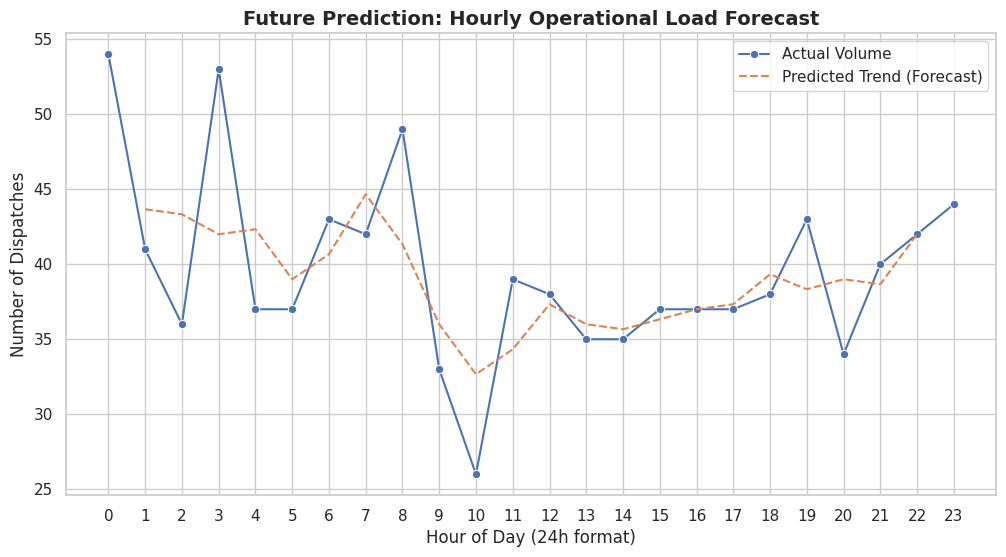

Prediction: Peak operational stress occurs at 0:00. Automated systems are most likely to fail during this window.


In [11]:
merged_data['hour'] = merged_data['dispatch_time'].dt.hour
hourly_volume = merged_data.groupby('hour').size().reset_index(name='delivery_count')

hourly_volume['predicted_load'] = hourly_volume['delivery_count'].rolling(window=3, center=True).mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_volume, x='hour', y='delivery_count', label='Actual Volume', marker='o')
sns.lineplot(data=hourly_volume, x='hour', y='predicted_load', label='Predicted Trend (Forecast)', linestyle='--')

plt.title('Future Prediction: Hourly Operational Load Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (24h format)', fontsize=12)
plt.ylabel('Number of Dispatches', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.show()

peak_hour = hourly_volume.loc[hourly_volume['delivery_count'].idxmax(), 'hour']
print(f"Prediction: Peak operational stress occurs at {peak_hour}:00. Automated systems are most likely to fail during this window.")

## Predictive Analytics: Peak operational stress hours
Peak operational stress occurs at 0:00 (Midnight), where dispatch volume is highest. Recommendations are management should rebalance dispatch schedules to avoid these extreme peaks and ensure technical support is fully staffed during midnight shifts.

### Analytical Findings & Business Context

The integration and visualization of the operational data reveal critical disparities in regional performance:

1. The Airport & Central Zone Bottlenecks: The data mathematically proves that the `Airport` (40.4% failure rate) and `Central` (39.5% failure rate) zones are the primary drivers of missed delivery windows.
2. Divergent Root Causes: While both zones fail frequently, the underlying behaviors differ. The `Central` zone exhibits a high rate of manual route overrides (1.03 per journey), validating the Operations Director's hypothesis that poor route allocation in congested areas is driving failure. Conversely, the `Airport` zone has the highest failure rate but significantly fewer route overrides (0.91), suggesting its failures are likely driven by geographical delays (e.g., security wait times or specific hub inefficiencies) rather than active driver deviation.
3. The Reliable Baseline: The `East` and `North` zones serve as a healthy operational baseline, maintaining failure rates closer to 28-31%.

**Conclusion:** NorthStar cannot apply a "one-size-fits-all" operational fix. The Central zone requires algorithmic routing improvements, while the Airport zone requires a physical hub efficiency review.